### Imports

In [9]:
import re
import os
import copy
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
)

### Parameters

In [ ]:

DATA_PATH = "cellula toxic data (1).csv"
TEXT_COLS = ["query", "image descriptions"]
LABEL_COL = "Toxic Category"
MIN_FREQ = 2
MAX_LEN_PERCENTILE = 95
EMBED_DIM = 100
HIDDEN_DIM = 128
DROPOUT = 0.3
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-3
SEED = 42


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


### Preprocessing

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)



def tokenize(text: str):
    text = str(text).lower()
    return word_tokenize(text)


def build_vocab(token_lists, min_freq=2):
    counter = Counter()
    for tokens in token_lists:
        counter.update(tokens)
    vocab = {"<pad>": 0, "<unk>": 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab


def encode_and_pad(tokens, vocab, max_len):
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens][:max_len]
    length = max(len(ids), 1)
    ids = ids + [vocab["<pad>"]] * (max_len - len(ids))
    return ids, length


class TextDataset(Dataset):
    def __init__(self, sequences, lengths, labels):
        self.sequences = torch.as_tensor(sequences, dtype=torch.long)
        self.lengths = torch.as_tensor(lengths, dtype=torch.long)
        self.labels = torch.as_tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.lengths[idx], self.labels[idx]

### LSTM Model

In [12]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        # bidirectional -> concatenated forward+backward hidden state, so 2x width
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 4, 64),  # Expects 512 (128 * 4) -> Outputs 64
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        # Output shape: (B, T, 2H)
        lstm_out, _ = self.lstm(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)

        # Pool across the time dimension (dim=1)
        avg_pool = torch.mean(lstm_out, dim=1)
        max_pool, _ = torch.max(lstm_out, dim=1)

        # Combine average context and peak feature signals
        pooled = torch.cat((avg_pool, max_pool), dim=1) # (B, 4H)
        out = self.dropout(pooled)
        return self.fc(out) # Self.fc input dim becomes hidden_dim * 4

### Training

In [13]:
def run_epoch(model, loader, criterion, device, optimizer=None, grad_clip=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for x, lengths, y in loader:
            x, y = x.to(device), y.to(device)

            if is_train:
                optimizer.zero_grad()

            logits = model(x, lengths)
            loss = criterion(logits, y)

            if is_train:
                loss.backward()
                if grad_clip:
                    nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, f1_macro, f1_weighted, all_preds, all_labels

### Graphs

In [ ]:
def plot_class_distribution(df, label_col):
    plt.figure(figsize=(9, 5))
    order = df[label_col].value_counts().index
    sns.countplot(y=df[label_col], order=order, hue=df[label_col], legend=False, palette="viridis")
    plt.title("Class Distribution")
    plt.xlabel("Count")
    plt.ylabel("Toxic Category")
    plt.tight_layout()
    plt.show()


def plot_training_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"], label="val")
    axes[0].set_title("Loss per Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_f1"], label="train (macro-F1)")
    axes[1].plot(epochs, history["val_f1"], label="val (macro-F1)")
    axes[1].set_title("Macro-F1 per Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Macro-F1")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix (Test Set)")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
def export_full_pdf_report(df, history, y_true, y_pred, class_names, output_filename="toxic_model_report.pdf"):
    print(f"Generating PDF report: {output_filename}...")

    with PdfPages(output_filename) as pdf:
        # Page 1: Dataset Summary & First 5 Rows
        fig, ax = plt.subplots(figsize=(11, 6))
        ax.axis("off")
        ax.set_title("Dataset Overview & Sample Entries", fontsize=14, fontweight="bold", pad=20)

        sample_df = df[TEXT_COLS + [LABEL_COL]].head(5)
        # Truncate text so it fits inside PDF cells
        sample_df_display = sample_df.copy()
        for col in TEXT_COLS:
            sample_df_display[col] = sample_df_display[col].astype(str).str.slice(0, 35) + "..."

        table_data = [sample_df_display.columns.tolist()] + sample_df_display.values.tolist()
        table = ax.table(cellText=table_data, loc="center", cellLoc="left")
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1.2, 1.8)
        pdf.savefig(fig, bbox_inches="tight")
        plt.close()

        # Page 2: Class Distribution Chart
        fig, ax = plt.subplots(figsize=(9, 5))
        order = df[LABEL_COL].value_counts().index
        sns.countplot(y=df[LABEL_COL], order=order, hue=df[LABEL_COL], legend=False, palette="viridis", ax=ax)
        ax.set_title("Class Distribution")
        ax.set_xlabel("Count")
        ax.set_ylabel("Toxic Category")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close()

        # Page 3: Training Curves
        epochs = range(1, len(history["train_loss"]) + 1)
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        axes[0].plot(epochs, history["train_loss"], label="train")
        axes[0].plot(epochs, history["val_loss"], label="val")
        axes[0].set_title("Loss per Epoch")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()

        axes[1].plot(epochs, history["train_f1"], label="train (macro-F1)")
        axes[1].plot(epochs, history["val_f1"], label="val (macro-F1)")
        axes[1].set_title("Macro-F1 per Epoch")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Macro-F1")
        axes[1].legend()
        pdf.savefig(fig, bbox_inches="tight")
        plt.close()

        # Page 4: Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        fig, ax = plt.subplots(figsize=(9, 7))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title("Confusion Matrix (Test Set)")
        plt.xticks(rotation=45, ha="right")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close()

    print(f"PDF successfully saved as '{output_filename}'!")    

### Main

Using device: cuda


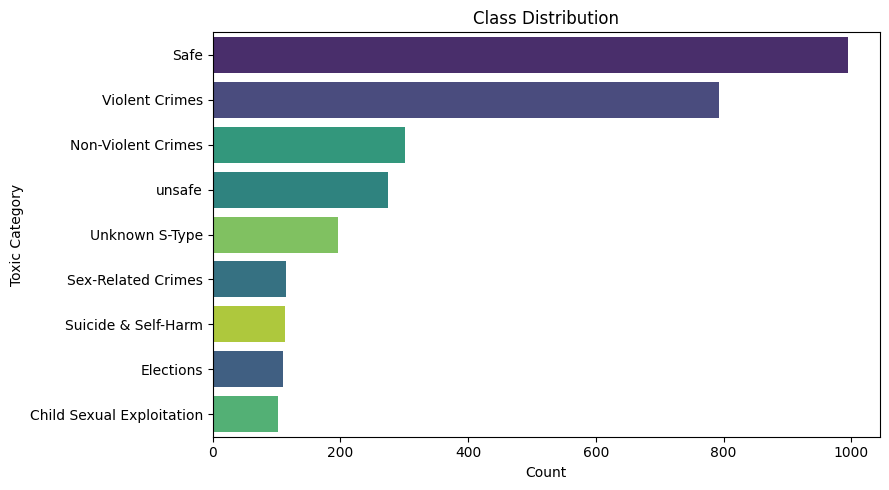

Classes (9): ['Child Sexual Exploitation', 'Elections', 'Non-Violent Crimes', 'Safe', 'Sex-Related Crimes', 'Suicide & Self-Harm', 'Unknown S-Type', 'Violent Crimes', 'unsafe']
Train/Val/Test sizes: 2100/450/450
Vocab size: 1565
Epoch 1 | Train Loss: 1.853 | Val Loss: 1.088 | Val F1: 0.775
Epoch 2 | Train Loss: 0.536 | Val Loss: 0.181 | Val F1: 0.941
Epoch 3 | Train Loss: 0.193 | Val Loss: 0.142 | Val F1: 0.942
Epoch 4 | Train Loss: 0.136 | Val Loss: 0.146 | Val F1: 0.926
Epoch 5 | Train Loss: 0.099 | Val Loss: 0.174 | Val F1: 0.934
Epoch 6 | Train Loss: 0.086 | Val Loss: 0.145 | Val F1: 0.926
Epoch 7 | Train Loss: 0.061 | Val Loss: 0.161 | Val F1: 0.932
Epoch 8 | Train Loss: 0.045 | Val Loss: 0.184 | Val F1: 0.942
Epoch 9 | Train Loss: 0.025 | Val Loss: 0.201 | Val F1: 0.937
Epoch 10 | Train Loss: 0.023 | Val Loss: 0.251 | Val F1: 0.938
Epoch 11 | Train Loss: 0.025 | Val Loss: 0.266 | Val F1: 0.918
Epoch 12 | Train Loss: 0.031 | Val Loss: 0.307 | Val F1: 0.941
Epoch 13 | Train Loss: 0

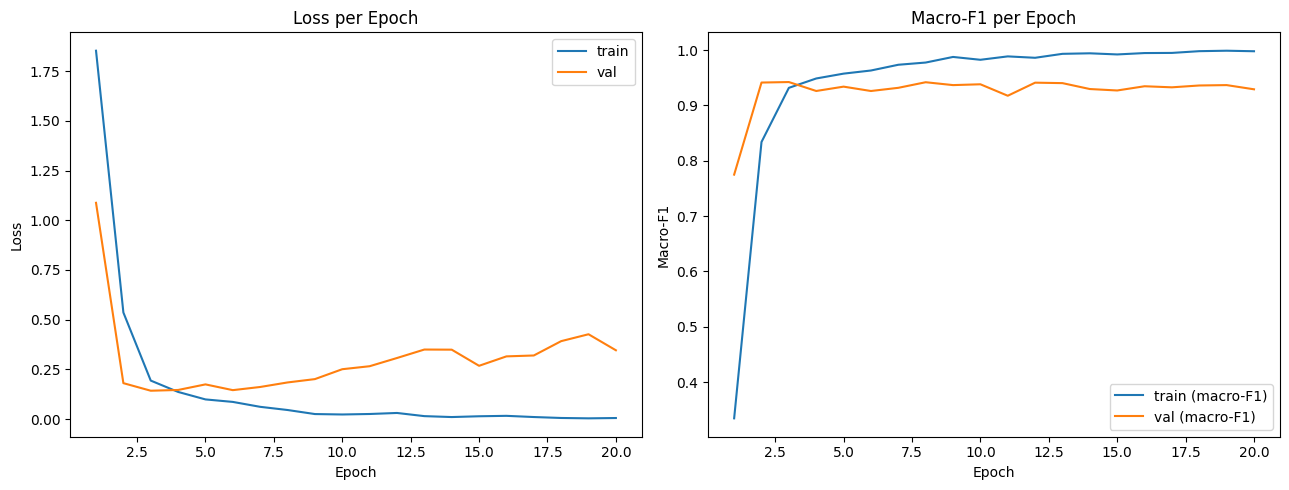


===== TEST SET RESULTS =====
Accuracy:      0.9311
Macro F1:      0.9287
Weighted F1:   0.9291

Per-class report:
                           precision    recall  f1-score   support

Child Sexual Exploitation       1.00      1.00      1.00        15
                Elections       1.00      1.00      1.00        17
       Non-Violent Crimes       0.90      0.98      0.94        45
                     Safe       0.89      0.95      0.92       150
       Sex-Related Crimes       1.00      0.94      0.97        17
      Suicide & Self-Harm       1.00      1.00      1.00        17
           Unknown S-Type       0.65      0.52      0.58        29
           Violent Crimes       1.00      0.93      0.97       119
                   unsafe       0.98      1.00      0.99        41

                 accuracy                           0.93       450
                macro avg       0.94      0.92      0.93       450
             weighted avg       0.93      0.93      0.93       450



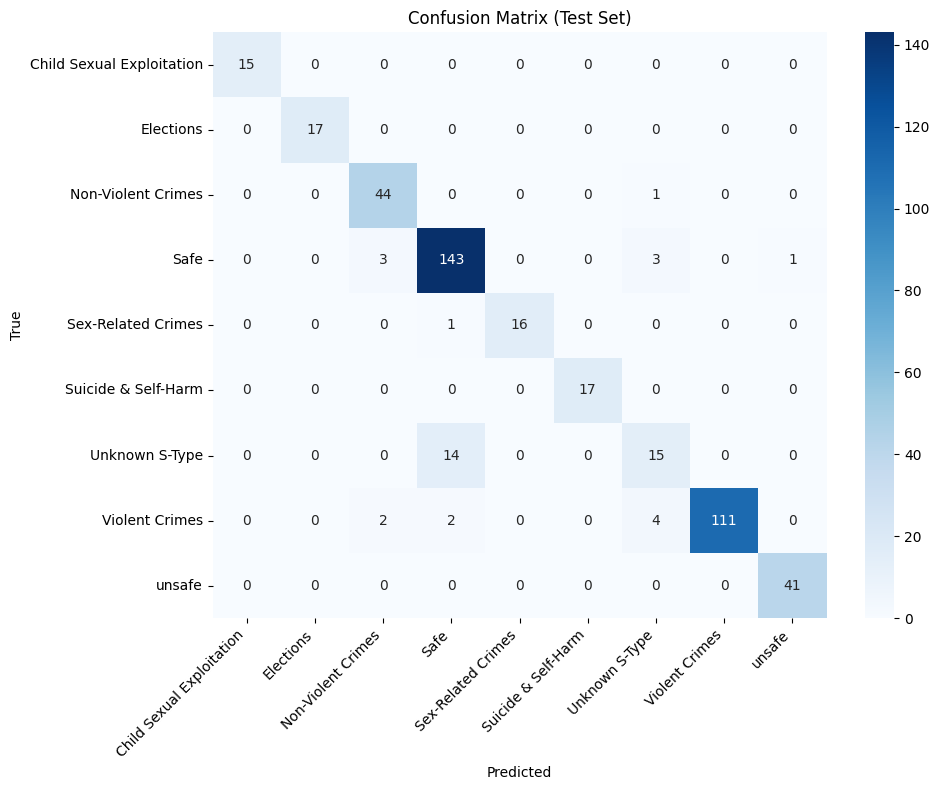

Generating PDF report: toxic_model_report.pdf...
PDF successfully saved as 'toxic_model_report.pdf'!


In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


df = pd.read_csv('cellula toxic data  (1).csv')
df = df.dropna(subset=TEXT_COLS + [LABEL_COL]).reset_index(drop=True)

plot_class_distribution(df, LABEL_COL)

# Combine text fields into one input string per row
df["text"] = df[TEXT_COLS[0]].astype(str)
for col in TEXT_COLS[1:]:
    df["text"] = df["text"] + " [SEP] " + df[col].astype(str)
df["tokens"] = df["text"].apply(tokenize)


label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df[LABEL_COL])
num_classes = len(label_encoder.classes_)
print(f"Classes ({num_classes}): {list(label_encoder.classes_)}")


idx = np.arange(len(df))
idx_train, idx_temp, y_train, y_temp = train_test_split(idx, y, test_size=0.3, random_state=SEED, stratify=y)



idx_val, idx_test, y_val, y_test = train_test_split(idx_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)
print(f"Train/Val/Test sizes: {len(idx_train)}/{len(idx_val)}/{len(idx_test)}")

tokens_train = df["tokens"].iloc[idx_train].tolist()
tokens_val = df["tokens"].iloc[idx_val].tolist()
tokens_test = df["tokens"].iloc[idx_test].tolist()


vocab = build_vocab(tokens_train, min_freq=MIN_FREQ)
print(f"Vocab size: {len(vocab)}")

train_lens = [len(t) for t in tokens_train]
max_len = int(np.percentile(train_lens, MAX_LEN_PERCENTILE))
max_len = max(max_len, 5)


def encode_set(token_lists):
    seqs, lens = [], []
    for tokens in token_lists:
        ids, length = encode_and_pad(tokens, vocab, max_len)
        seqs.append(ids)
        lens.append(length)
    return np.array(seqs), np.array(lens)

X_train, len_train = encode_set(tokens_train)
X_val, len_val = encode_set(tokens_val)
X_test, len_test = encode_set(tokens_test)

train_ds = TextDataset(X_train, len_train, y_train)
val_ds = TextDataset(X_val, len_val, y_val)
test_ds = TextDataset(X_test, len_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


class_weights = compute_class_weight( # to give more weight to the minority classes during training
    "balanced", classes=np.arange(num_classes), y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

model = BiLSTMClassifier(
        vocab_size=len(vocab),
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        num_classes=num_classes,
        pad_idx=vocab["<pad>"],
        dropout=DROPOUT,
    ).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(
    model.parameters(), lr=LR
)

# Training loop
history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
best_val_f1 = -1.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_f1, _, _, _ = run_epoch(
        model, train_loader, criterion, device, optimizer=optimizer, grad_clip=5.0
    )
    val_loss, val_acc, val_f1, _, _, _ = run_epoch(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch} | Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f} | Val F1: {val_f1:.3f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_state)
print(f"\nBest validation macro-F1: {best_val_f1:.4f}")

plot_training_curves(history)

#test evaluation
test_loss, test_acc, test_f1_macro, test_f1_weighted, test_preds, test_labels = run_epoch(
    model, test_loader, criterion, device
)

print("\n===== TEST SET RESULTS =====")
print(f"Accuracy:      {test_acc:.4f}")
print(f"Macro F1:      {test_f1_macro:.4f}")
print(f"Weighted F1:   {test_f1_weighted:.4f}")
print("\nPer-class report:")
print(
    classification_report(
        test_labels, test_preds,
        target_names=label_encoder.classes_,
    )
)

plot_confusion_matrix(test_labels, test_preds, label_encoder.classes_)


export_full_pdf_report(
    df=df,
    history=history,
    y_true=test_labels,
    y_pred=test_preds,
    class_names=label_encoder.classes_,
    output_filename="toxic_model_report.pdf"
)